<a href="https://colab.research.google.com/github/kedarpinniboyina/ML-Salary-Prediction-Linear-Regression/blob/main/Salary_Prediction_Based_on_Experience_Using_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Gradio For UI (only for Colab)

In [24]:
!pip install gradio

Import Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gradio as gr

Load Dataset

In [6]:
data = pd.read_csv('Salary_Data.csv')
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


Understand Data

In [7]:
print(data.shape)
print(data.info())
print(data.describe())

(30, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


Split Features & Target

In [8]:
X = data[['YearsExperience']]
y = data['Salary']

Split Train-Test data

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train Model

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Evaluation

In [27]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2*100)
print("MAE:", mae)
print("MSE:", mse)

R2 Score: 90.24461774180497
MAE: 6286.453830757749
MSE: 49830096.85590839


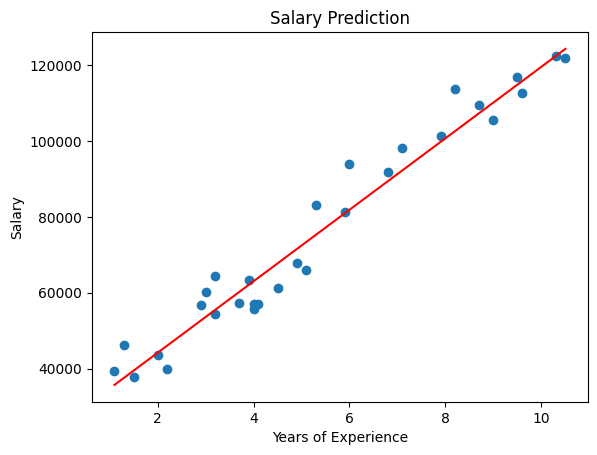

In [29]:
plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction")
plt.show()

In [37]:
exp = float(input("Enter years of experience: "))
pred_salary = model.predict([[exp]])

print("Predicted Salary:", pred_salary[0])

Enter years of experience: 2.5
Predicted Salary: 48881.12131935425


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Gradio UI

In [35]:
interface = gr.Interface(
    fn=predict_salary,
    inputs=gr.Slider(0, 20, step=0.5, label="Years of Experience"),
    outputs=gr.Textbox(label="Salary Result"),
    title="💼 Salary Prediction App",
    description="Predict salary based on experience using Linear Regression",
)

Launch App

In [36]:

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7b2ec4daae0a3e4e79.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
